<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/BasicML/BasicML/PortfolioOptimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

In [ ]:
import yfinance as yf

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']
start = '2019-01-01'
end = '2024-01-01'

prices = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=True
)['Close']

prices.tail()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOGL,META,MSFT
Date,,,,,
2023-12-22,191.788742,153.419998,140.428955,350.938568,369.077148
2023-12-26,191.243927,153.410004,140.458755,352.368591,369.155945
2023-12-27,191.342972,153.339996,139.317368,355.347778,368.574615
2023-12-28,191.768951,153.380005,139.178406,355.834320,369.766876
2023-12-29,190.728775,151.940002,138.642456,351.504608,370.515656


In [ ]:
returns = np.log(prices / prices.shift(1)).dropna()

In [ ]:
assert isinstance(returns.index, pd.DatetimeIndex)
assert returns.isnull().sum().sum() == 0

In [ ]:
TRADING_DAYS = 252

In [ ]:
rf = yf.download(
    '^IRX',
    start=returns.index.min(),
    end=returns.index.max(),
    auto_adjust=True
)['Close']

rf = rf / 100          # percent → decimal
rf_daily = rf / 252    # annual → daily

rf_daily = rf_daily.reindex(returns.index).ffill()

rf_annual = rf_daily.mean() * 252

[*********************100%***********************]  1 of 1 completed


In [ ]:
assert rf_annual.isnull().sum() == 0

In [ ]:
mu = returns.mean() * TRADING_DAYS      # Expected annual returns
S  = returns.cov() * TRADING_DAYS       # Annualized covariance matrix

print(mu)
print(S)

Ticker
AAPL     0.325871
AMZN     0.136374
GOOGL    0.195298
META     0.192235
MSFT     0.273673
dtype: float64
Ticker      AAPL      AMZN     GOOGL      META      MSFT
Ticker                                                  
AAPL    0.104004  0.070512  0.069606  0.083695  0.074851
AMZN    0.070512  0.124001  0.074245  0.095182  0.073541
GOOGL   0.069606  0.074245  0.101372  0.093611  0.073858
META    0.083695  0.095182  0.093611  0.195889  0.083134
MSFT    0.074851  0.073541  0.073858  0.083134  0.093052


In [ ]:
assert mu.shape[0] == S.shape[0] == S.shape[1]

In [ ]:
num_assets = len(mu)
asset_names = mu.index.tolist()

In [ ]:
def portfolio_return(weights, mu):
    return np.dot(weights, mu)

def portfolio_volatility(weights, S):
    return np.sqrt(weights.T @ S @ weights)

def portfolio_sharpe(weights, mu, S, rf):
    ret = np.dot(weights, mu)
    vol = np.sqrt(weights.T @ S @ weights)
    return (ret - rf) / vol

In [ ]:
def random_weights(n):
    w = np.random.random(n)
    return w / np.sum(w)

In [ ]:
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
initial_guess = np.ones(num_assets) / num_assets

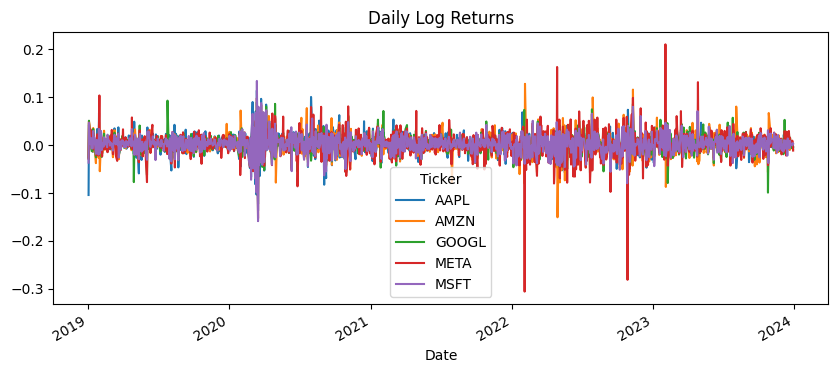

In [ ]:
returns.plot(title='Daily Log Returns', figsize=(10,4))
plt.show()

In [ ]:
def negative_sharpe(weights, mu, S, rf):
    return -portfolio_sharpe(weights, mu, S, rf)

In [ ]:
result = minimize(
    negative_sharpe,
    initial_guess,
    args=(mu, S, rf_annual),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

weights_max_sharpe = result.x

In [ ]:
def portfolio_volatility(weights, S):
    return np.sqrt(weights.T @ S @ weights)

result_min_var = minimize(
    portfolio_volatility,
    initial_guess,
    args=(S,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

weights_min_var = result_min_var.x

In [ ]:
num_portfolios = 5000

port_returns = []
port_vols = []
port_sharpes = []

for _ in range(num_portfolios):
    w = random_weights(num_assets)

    ret = portfolio_return(w, mu)
    vol = portfolio_volatility(w, S)
    sharpe = (ret - rf_annual) / vol

    port_returns.append(ret)
    port_vols.append(vol)
    port_sharpes.append(sharpe)

In [ ]:
port_returns = np.array(port_returns)
port_vols = np.array(port_vols)
port_sharpes = np.array(port_sharpes)

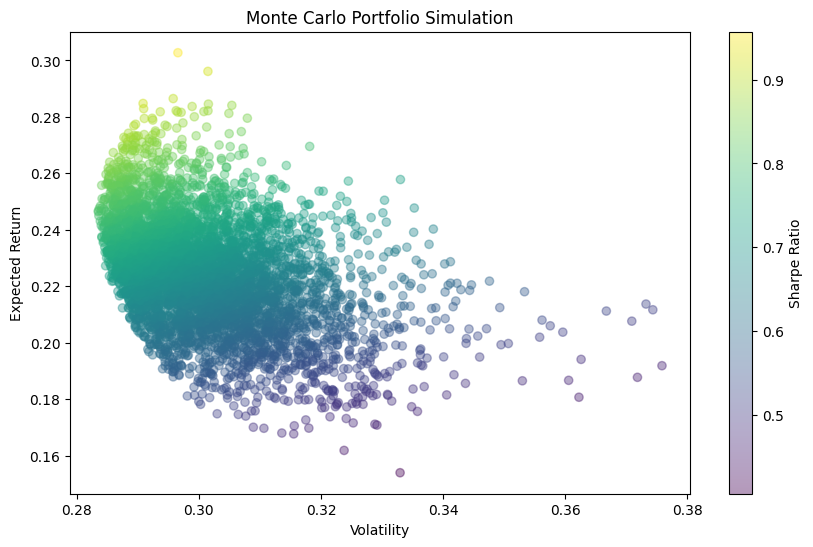

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(
    port_vols,
    port_returns,
    c=port_sharpes,
    cmap='viridis',
    alpha=0.4
)
plt.colorbar(label='Sharpe Ratio')

plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.title('Monte Carlo Portfolio Simulation')

plt.show()

In [ ]:
ret_max_sharpe = portfolio_return(weights_max_sharpe, mu)
vol_max_sharpe = portfolio_volatility(weights_max_sharpe, S)

ret_min_var = portfolio_return(weights_min_var, mu)
vol_min_var = portfolio_volatility(weights_min_var, S)

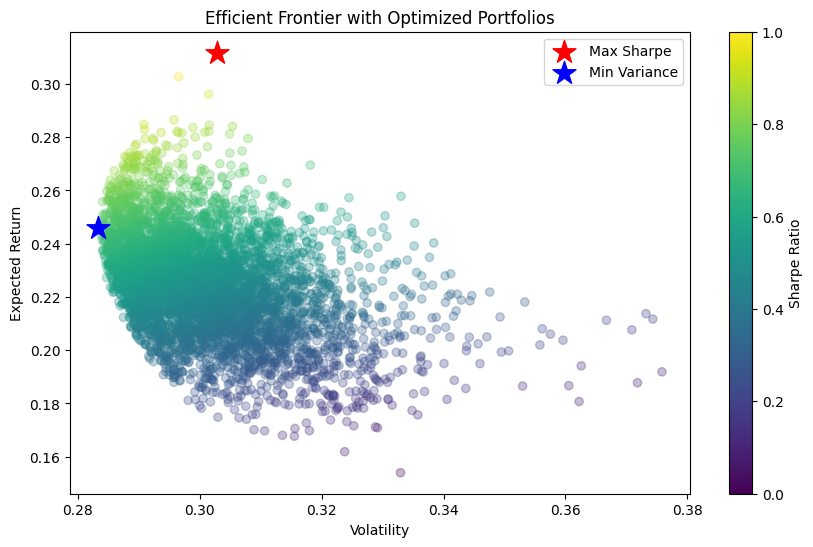

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    port_vols,
    port_returns,
    c=port_sharpes,
    cmap='viridis',
    alpha=0.3
)

plt.scatter(
    vol_max_sharpe,
    ret_max_sharpe,
    marker='*',
    color='red',
    s=300,
    label='Max Sharpe'
)

plt.scatter(
    vol_min_var,
    ret_min_var,
    marker='*',
    color='blue',
    s=300,
    label='Min Variance'
)

plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.legend()
plt.title('Efficient Frontier with Optimized Portfolios')

plt.show()

In [ ]:
weights_df = pd.DataFrame({
    'Asset': asset_names,
    'Weight': weights_max_sharpe
}).sort_values('Weight', ascending=False)

weights_df

,Asset,Weight
0,AAPL,7.293575e-01
4,MSFT,2.706425e-01
2,GOOGL,2.385245e-18
1,AMZN,0.000000e+00
3,META,0.000000e+00


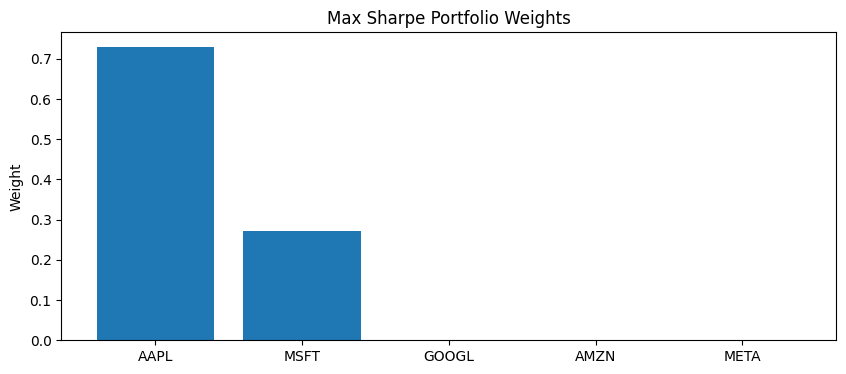

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(weights_df['Asset'], weights_df['Weight'])
plt.title('Max Sharpe Portfolio Weights')
plt.ylabel('Weight')
plt.show()

In [ ]:
w_equal = np.ones(num_assets) / num_assets

ret_equal = portfolio_return(w_equal, mu)
vol_equal = portfolio_volatility(w_equal, S)
sharpe_equal = (ret_equal - rf_annual) / vol_equal

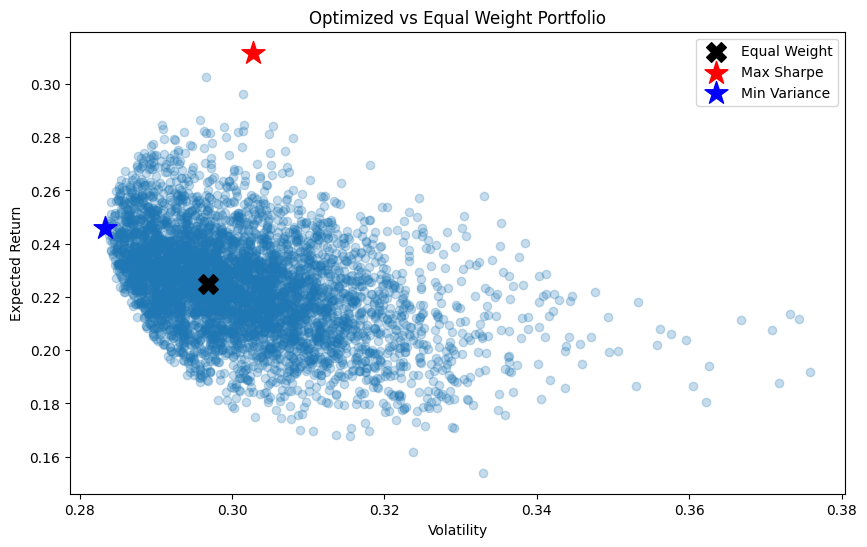

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(port_vols, port_returns, alpha=0.25)

plt.scatter(vol_equal, ret_equal,
            color='black', s=200, marker='X',
            label='Equal Weight')

plt.scatter(vol_max_sharpe, ret_max_sharpe,
            color='red', s=300, marker='*',
            label='Max Sharpe')

plt.scatter(vol_min_var, ret_min_var,
            color='blue', s=300, marker='*',
            label='Min Variance')

plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.legend()
plt.title('Optimized vs Equal Weight Portfolio')

plt.show()

In [ ]:
target_returns = np.linspace(
    mu.min(),
    mu.max(),
    50   # number of frontier points
)

In [ ]:
frontier_vols = []
frontier_rets = []

for target in target_returns:

    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, t=target: np.dot(w, mu.values) - t}
    )

    result = minimize(
        portfolio_volatility,
        initial_guess,
        args=(S,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        frontier_vols.append(result.fun)
        frontier_rets.append(target)

In [ ]:
frontier_vols = np.array(frontier_vols)
frontier_rets = np.array(frontier_rets)

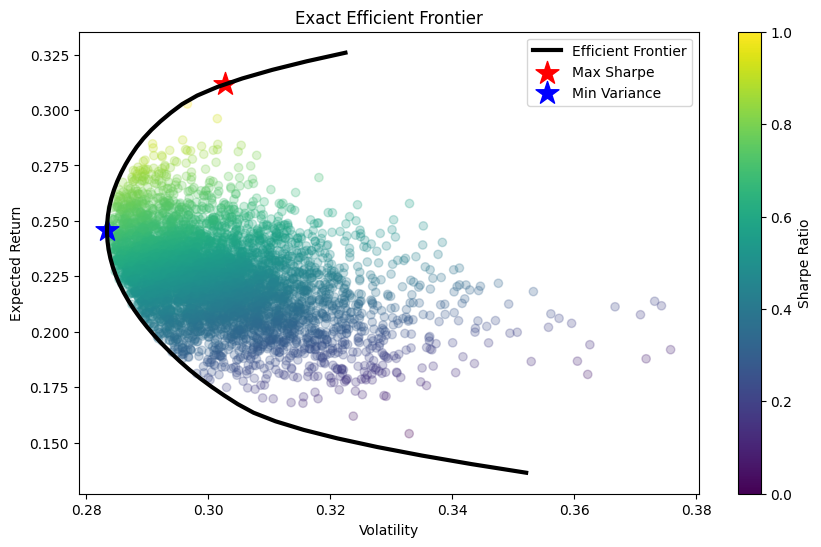

In [ ]:
plt.figure(figsize=(10, 6))

# Monte Carlo portfolios
plt.scatter(
    port_vols,
    port_returns,
    c=port_sharpes,
    cmap='viridis',
    alpha=0.25
)

# Exact efficient frontier
plt.plot(
    frontier_vols,
    frontier_rets,
    color='black',
    linewidth=3,
    label='Efficient Frontier'
)

# Optimized portfolios
plt.scatter(vol_max_sharpe, ret_max_sharpe,
            color='red', marker='*', s=300, label='Max Sharpe')

plt.scatter(vol_min_var, ret_min_var,
            color='blue', marker='*', s=300, label='Min Variance')

plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.title('Exact Efficient Frontier')
plt.legend()
plt.show()

# Minimum Variance Portfolio

Objective:
* Minimize volatility

Properties:
* Lowest possible risk
* Often dominated by:
  * Low-vol stocks
  * Bonds / defensive assets
* Independent of expected returns (mostly)

When it is optimal:
* Extremely risk-averse investors
* Capital preservation
* Benchmark-relative risk control
* Bear markets

Interpretation:
* “This is the safest portfolio money can buy.”

# Maximum Sharpe Portfolio (Tangency Portfolio)

Objective:
* Maximize (Return − Risk-Free) / Risk

Properties:
* Best risk-adjusted return
* Depends heavily on:
  * Expected returns
  * Risk-free rate
* Often concentrated (corner solutions)

When it is optimal:
* Mean–variance investors
* Long-only with no leverage
* When expected returns are reliable
* Capital allocation with a risk-free asset

Interpretation:
* “This portfolio gives the most return per unit of risk.”

# Capital Market Line (CML)

Once a risk-free asset exists:

* The Maximum Sharpe portfolio is the only risky portfolio that rational investors should hold.

Investors then adjust risk by:
* Mixing risk-free asset
* With Max Sharpe portfolio

This is a foundational result in finance.